# Егзопланети
### Примена на машинско учење за класификација на егзопланети детектирани со мисијата Kepler

Даниел Јосифовски, бр. на индекс: 33/2016

26.9.2020, Скопје

### Содржина

* [I. Вовед](#chapter1)
    * [I.1 Eгзопланети](#section_1_1)
    * [I.2 Мисијатa Kepler](#section_1_2)
* [II. Податочно множество](#chapter2)
* [III. Поставување на проблемот](#chapter3)
    * [III.1 Алгоритми](#section_3_1)
    * [III.2 Поделба на податочното множество](#section_3_2)
* [IV. Решавање на проблемот](#chapter4)
    * [IV.1 Импортирање библиотеки](#section_4_1)
    * [IV.2 Вчитување на податочното множество](#section_4_2)
        * [IV.2.1 Запознавање со множеството](#section_4_2_1)
    * [IV.3 Поделба на множеството на множества за тренирање, и за тестирање](#section_4_3)
    * [IV.4 Претпроцесирање на податоците](#section_4_4)
        * [IV.4.1 Exploratory Data Analysis](#section_4_4_1)
        * [IV.4.2 Графици](#section_4_4_2)
    * [IV.5 Тренирање на моделите](#section_4_5)
        * [IV.5.1 Logistic Regression](#section_4_5_1)
        * [IV.5.2 Support Vector Machines](#section_4_5_2)
        * [IV.5.3 k-Nearest Neighbors](#section_4_5_3)
        * [IV.5.4 Naive Bayes](#section_4_5_4)
        * [IV.5.5 Decision Trees](#section_4_5_5)
        * [IV.5.6 Random Forest](#section_4_5_6)
    * [IV.6 Вкрстена валидација](#section_4_6)
    * [IV.7 Нагодување на хипер-параметрите](#section_4_7)
    * [IV.8 Метрика за евалуација на моделите](#section_4_8)
    * [IV.9 Избор на модел](#section_4_9)
* [V. Откривање планети](#chapter5)
* [VI. Еволуција на решението](#chapter6)
* [VII. Референци](#chapter7)

### I. Вовед <a class="anchor" id="chapter1"></a>

#### I.1 Егзопланети <a class="anchor" id="section_1_1"></a>
Егзопланети се планети кои се наоѓаат надвор од Сончевиот систем, односно ротираат околу друга ѕвезда. Многу е тешко да се детектираат планети кои се неколку светлински години оддалечени од Земјата затоа што се со релативно мали димензии и се многу бледи споредено со ѕвездата околу која ротираат. Но, последните две декади астрономите развиле методи за индиректна детекција на планети врз база на ефектите кои ги имаат планетите на ѕвездата. Досега се откриени вкупно 4201 егзопланета. На Слика 1 е прикажана првата направена слика од егзопланетата наречена 2M1207b во 2004 година оддалечена 230 светлински години.

<img src="images\first_exoplanet.jpg" width="500" height="500" align="center"/>

<figcaption style="text-align:center"><b>Слика 1.</b> Првата слика од егзопланета <br> [<a href="https://exoplanets.nasa.gov/resources/300/2m1207b-first-image-of-an-exoplanet/">url</a>; последен пристап 30.8.2020]</figcaption>


Методи за детекција на егзопланети, како и тоа колку планети се откриени со секој од методите се прикажани во табелата подолу.

| Метод | Број на откриени планети |
| :--- | :--- |
| транзит на планетата пред ѕвездата | 3191 |
| радијална брзина | 810 |
| гравитациски леќи | 96 |
| снимање | 50 |
| варијации на времето на транзит | 21 |
| варијации во времето на затемнување | 16 |
| варијации во времето на емитување радиобранови на пулсари | 7 |
| модулација на орбиталната блескавост | 6 |
| варијации во времето на пулсирање | 2 |
| астрометрија | 1 |
| кинематика на диск | 1 |

На 6 октомври 1995 година откриена е првата егзопланета наречена 51 Pegasi b која е оддалечена 50 светлински години од Земјата. Оваа планета е откриена со методот на радијална брзина од научниците Michel Mayor и Didier Queloz.

#### I.2 Мисијатa Kepler <a class="anchor" id="section_1_2"></a>
Во 2009 година NASA го лансирала вселенското летало Kepler со цел да бара егзопланети. На Слика 2 е прикажано леталото.

<img src="images\Kepler.jpg" width="500" height="500" align="center"/>

<figcaption style="text-align:center"><b>Слика 2.</b> Kepler <br> [<a href="https://www.jpl.nasa.gov/missions/kepler/">url</a>; последен пристап 30.8.2020]</figcaption>

Kepler детектирал планети со транзитниот метод. Времето кога планетата се наоѓа пред ѕвездата се нарекува транзит, па кога планетата транзитира пред својата ѕвезда, блокира дел од светлината на ѕвездата. Тоа значи дека ѕвездата тогаш е помалку блексава, и астрономите може да ја набљудуваат оваа промена. На овој начин може да се определи и големината на планетата. На Слика 3 е прикажан транзитот на две планети.

<img src="images\exoplanet-transit-diagram.gif" width="500" height="500" align="center"/>

<figcaption style="text-align:center"><b>Слика 3.</b> Транзит на планети <br> [<a href="https://spaceplace.nasa.gov/transits/en/">url</a>; последен пристап 30.8.2020]</figcaption>

### II. Податочно множество <a class="anchor" id="chapter2"></a>
Податочното множество може да се подели на неколку делови:
* [Колони за идентификација (ориг. Identification Columns)](#section1)
* [Информација за архива на егзопланети (ориг. Exoplanet Archive Information)](#section2)
* [Колони за склоност на проектот (ориг. Project Disposition Columns)](#section3)
* [Својства на транзитот (ориг. Transit Properties)](#section4)
* [Информаци за праг на настани за премин (ориг. Threshold-Crossing Event (TCE) Information)](#section5)
* [Параметри на ѕвездите (ориг. Stellar Parameters)](#section6)
* [KIC Параметри (ориг. KIC Parameters)](#section7)

Опис на секоја од колоните од податочното множество:

##### Колони за идентификација <a class="anchor" id="section1"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| kepid | KepID | Идентификациски број на целта која е снимана како што е наведено во Kepler Input Catalog (KIC). |
| kepoi_name | KOI Name | Број кој се користи да се идентификува и да се следи објект од интерес за Kepler (Kepler Object of Interest - KOI). KOI е цел идентификувана од Kepler која има транзит кој наликува на оној на планета. |

##### Информација за архива на егзопланети <a class="anchor" id="section2"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| kepler_name | Kepler Name | Име за идентификација на планетата, кое е полесно да се запомни од KOI или KIC/KepID именувањето. |
| koi_disposition | Exoplanet Archive Disposition | Склоноста дали објектот е планета или не. Вредности на оваа карактеристика се CANDIDATE, FALSE POSITIVE, и CONFIRMED. |

##### Колони за склоност на проектот <a class="anchor" id="section3"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| koi_pdisposition | Disposition Using Kepler Data | Склоноста на анализата на податоците на Kepler кон секој кандидат дали е планета или не. Вредности на оваа карактеристика се FALSE POSITIVE, и CANDIDATE. Вредностите на оваа карактеристика може да се ажурираат во согласност со новите анализи на податоците. FALSE POSITIVE значи дека снимениот објект не поминал барем еден од тестовите за тоа дали е планета или не. CANDIDATE значи дека објектот ги поминал сите тестови за да се утврди дали е FALSE POSITIVE, но тоа не значи a priori дека сите можни тестови се поминати, па овој KOI може да биде класифициран и како FALSE POSITIVE. |
| koi_score | Disposition Score | Вредност помеѓу 0 и 1 која укажува доверливост за склоноста на KOI. За CANDIDATE повисока вредност значи поголема доверливост во склоноста, а за FALSE POSITIVE повисока вредност значи помала доверливост во склоноста. |
| koi_fpflag_nt | Not Transit-Like False Positive Flag | KOI чијашто светлинска крива не е конзистентна со таа на планета која транзитира. Настанува поради артефакти во инструментите, како и неколку други причини. |
| koi_fpflag_ss | Stellar Eclipse False Positive Flag | KOI кое укажува дека транзитот најверојатно потекнува од бинарна ѕвезда. |
| koi_fpflag_co | Centroid Offset False Positive Flag | Изворот на сигналот е некоја ѕвезда во близина. |
| koi_fpflag_ec | Ephemeris Match Indicates Contamination False Positive Flag | KOI има ист период и епоха како друг објект и се смета дека е резултат од загадување на флуксот во апертурата или преслушување во електронските компоненти. |

##### Својства на транзитот <a class="anchor" id="section4"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| koi_period | Orbital Period [days] | Орбитален период е интервалот помеѓу последователни транзити на планетата, изразен во денови. |
| koi_period_err1 |  | Горна граница на интервалот на неодреденост на орбиталниот период, изразена во денови. |
| koi_period_err2 |  | Долна граница на интервалот на неодреденост на орбиталниот период, изразена во денови. |
| koi_time0bk | Transit Epoch (BJD - 2,454,833.0) | Транзитната епоха е времето кое соодветствува на центарот на првиот детектиран транзит во барицентричниот Јулијанов ден - Barycentric Julian Day (BJD) минус константен офсет од 2 454 833 денови. Офсетот одговара на 12.00 1 јануари 2009 UTC. |
| koi_time0bk_err1 |  | Горна граница на интервалот на неодреденост на транзитната епоха, изразена во BKJD. |
| koi_time0bk_err2 |  | Долна граница на интервалот на неодреденост на транзитната епоха, изразена во BKJD. |
| koi_impact | Impact Parameter | Параметар на импакт е небесното растојание помеѓу центарот на ѕвездениот диск и центарот на планетарниот диск кога се во иста линија, нормализирани со ѕвездениот радиус. |
| koi_impact_err1 |  | Горна граница на интервалот на неодреденост на параметарот на импакт. |
| koi_impact_err2 |  | Долна граница на интервалот на неодреденост на параметарот на импакт. |
| koi_duration | Transit Duration [hrs] | Времетраење на транзитот на објектот, изразено во часови. Се определува од првиот контакт помеѓу планетата и ѕвездата до последниот контакт. |
| koi_duration_err1 |  | Горна граница на интервалот на неодреденост на времетраење на транзитот, изразено во часови. |
| koi_duration_err2 |  | Долна граница на интервалот на неодреденост на времетраење на транзитот, изразено во часови. |
| koi_depth | Transit Depth [parts per million] | Длабочина на транзит е дел од ѕвездениот флукс кој се губи во минимумот на транзитот на планетата, изразен во дел од милион. |
| koi_depth_err1 |  | Горна граница на интервалот на неодреденост на длабочина на транзитот, изразена во дел од милион. |
| koi_depth_err2 |  | Долна граница на интервалот на неодреденост на длабочина на транзитот, изразена во дел од милион. |
| koi_prad | Planetary Radius [Earth radii] | Радиус на планетата, изразен во Земјини радиуси. |
| koi_prad_err1 |  | Горна граница на интервалот на неодреденост на радиус на планетата, изразен во Земјини радиуси. |
| koi_prad_err2 |  | Долна граница на интервалот на неодреденост на радиус на планетата, изразен во Земјини радиуси. |
| koi_teq | Equilibrium Temperature [K] | Апроксимација за температурата на планетата, изразена во келвини. |
| koi_teq_err1 |  | Горна граница на интервалот на неодреденост на рамнотежната температура, изразена во келвини. |
| koi_teq_err2 |  | Долна граница на интервалот на неодреденостна рамнотежната температура, изразена во келвини. |
| koi_insol | Insolation Flux [Earth flux] | Флуксот од изложувањето на сонце е друг начин да се апроксимира температурата на планетата, изразен во единици релативни во однос на тие измерени за Земјата од Сонцето. |
| koi_insol_err1 |  | Горна граница на интервалот на неодреденост на флуксот од изложувањето на сонце, изразен во единици релативни во однос на тие измерени за Земјата од Сонцето. |
| koi_insol_err2 |  | Долна граница на интервалот на неодреденост на флуксот од изложувањето на сонце, изразен во единици релативни во однос на тие измерени за Земјата од Сонцето. |

##### Информаци за праг на настани за премин <a class="anchor" id="section5"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| koi_model_snr | Transit Signal-to-Noise | Длабочината на транзитот нормализирана со средната вредност на неодреденоста во флуксот за време на транзитот. |
| koi_tce_plnt_num | TCE Planet Number | TCE Planet Number обединет со KOI. |
| koi_tce_delivname | TCE Delivery Name | TCE delivery Name кое соодветствува со TCE податоците обединети со KOI. |

##### Параметри на ѕвездите <a class="anchor" id="section6"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| koi_steff | Stellar Effective Temperature [K] | Температура на фотосферата на ѕвездата, изразена во келвини. |
| koi_steff_err1 |  | Горна граница на интервалот на неодреденост на температура на фотосферата на ѕвездата, изразена во келвини. |
| koi_steff_err2 |  | Долна граница на интервалот на неодреденост на температура на фотосферата на ѕвездата, изразена во келвини. |
| koi_slogg | Stellar Surface Gravity [$ \log_{10}(cm/s^{2}) $] | Логаритам со основа 10 на забрзувањето поради гравитација на површината на ѕвездата, изразена во $ \log_{10}(cm/s^{2}) $. |
| koi_slogg_err1 |  | Горна граница на интервалот на неодреденост на забрзувањето поради гравитација на површината на ѕвездата, изразена во $ \log_{10}(cm/s^{2}) $. |
| koi_slogg_err2 |  | Долна граница на интервалот на неодреденост на забрзувањето поради гравитација на површината на ѕвездата, изразена во $ \log_{10}(cm/s^{2}) $. |
| koi_srad | Stellar Radius [Solar radii] | Радиусот на фотосферата на ѕвездата, изразен во Сончеви радиуси. |
| koi_srad_err1 |  | Горна граница на интервалот на неодреденост на радиусот на фотосферата на ѕвездата, изразен во Сончеви радиуси. |
| koi_srad_err2 |  | Долна граница на интервалот на неодреденост на радиусот на фотосферата на ѕвездата, изразен во Сончеви радиуси. |

##### KIC Параметри <a class="anchor" id="section7"></a>
| Име во базата на податоци | Ознака во табелата | Опис |
| :--- | :--- | :--- |
| ra | RA [decimal degrees] | Десно возвишување на KIC. |
| dec | Dec [decimal degrees] | Деклинација на KIC. |
| koi_kepmag | Kepler-band [mag] | Опсег на Kepler. |

Податочното множество е преземено од Веб-страницата на институтот за истражување на егзопланети на NASA \[[4](#ref4)\], каде што може да се прочитаат многу повеќе детали во врска со податочното множество \[[5](#ref5)\].

### III. Поставување на проблемот <a class="anchor" id="chapter3"></a>
Целта на овој проект е според карактеристиките на снимените објекти од сателитот да се направи бинарна класификација дали снимениот објект е егзопланета или не. Карактеристиката koi_disposition е излезната карактеристика која сакаме да ја предвидуваме.

#### III.1 Алгоритми <a class="anchor" id="section_3_1"></a>
За решавање на овој проблем, ќе бидат искористени следниве алгоритми:
- [Logistic Regression](#section_4_5_1)
- [Support Vector Machines](#section_4_5_2)
- [k-Nearest Neighbors](#section_4_5_3)
- [Naive Bayes](#section_4_5_4)
- [Decision Trees](#section_4_5_5)
- [Random Forest](#section_4_5_6)

#### III.2 Поделба на податочното множество <a class="anchor" id="section_3_2"></a>
Излезната карактеристика содржи три различни вредности: CONFIRMED, FALSE POSITIVE, CANDIDATE. Во табелата подолу е дадено значењето на секоја од овие вредности.

| Вредност | Значење |
| :--- | :--- |
| CONFIRMED | Потврдено дека објектот е планета |
| FALSE POSITIVE | Потвредно дека објектот не е планета |
| CANDIDATE | Треба да се утврди дали објектот е планета или не |

Поради тоа, податочното множество ќе го поделиме на два дела:
1. дел кој ги содржи сите објекти за кои се знае што се' (планета или нешто друго),
2. дел кој ги содржи кандидатите за планети, и на овој дел ќе се примени избраниот модел со цел да утврдиме кои од снимените објекти се планети. 

### IV. Решавање на проблемот <a class="anchor" id="chapter4"></a>

#### IV.1 Импортирање библиотеки <a class="anchor" id="section_4_1"></a>

Во првиот дел ги импортираме библиотеките за работа со податоци.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn')

Во вториот дел ги импортираме библиотеките за претпроцесирање на податочното множество.

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier

Во третиот дел ги импортираме библиотеките кои ги содржат моделите за машинско учење кои ќе бидат применети врз процесираното податочно множество.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Во четвртиот дел ги импортираме библиотеките за метрика.

In [4]:
from sklearn.metrics import f1_score
from sklearn.metrics import plot_confusion_matrix

#### IV.2 Вчитување на податочното множество <a class="anchor" id="section_4_2"></a>

In [5]:
path = 'data//'
exoplanets_data = pd.read_csv(path + 'KOI_Table_Cumulative_list.csv')
exoplanets_data

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,0,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,10155286,K07988.01,NaN,CANDIDATE,CANDIDATE,0.092,0,0,0,0,...,-128.0,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998


##### IV.2.1 Запознавање со множеството <a class="anchor" id="section_4_2_1"></a>

Прво ќе се запознаеме со податоците на множеството, и ќе направиме првично претпроцесирање кое не може да има влијание врз понатамошното претпроцесирање на множеството, но може многу да нѝ ја олесни работата понатаму. Ова го правиме затоа што не смееме да правиме претпроцесирање на целото податочно множество, а потоа да го поделиме на множества за тренирање и за тестирање затоа што може да пренесеме информации во множеството за тестирање.

###### Проверка на уникатни вредности
За да провериме уникатни вредности на секоја карактеристика, ќе ја искористиме функцијата **uniqueValues(df)**, каде како аргумент предаваме DataFrame, а го добиваме бројот на уникатни вредности за секоја карактеристика.

In [6]:
def uniqueValues(df):
    for column in df:
        unique_values = df[column].unique()
        number_values = len(unique_values)
        if number_values <= 10:
            print(f'Number of unique values for feature {column} is: {number_values} -- {unique_values}')
        else:
            print(f'Number of unique values for feature {column} is: {number_values}')

In [7]:
uniqueValues(exoplanets_data)

Number of unique values for feature kepid is: 8214
Number of unique values for feature kepoi_name is: 9564
Number of unique values for feature kepler_name is: 2309
Number of unique values for feature koi_disposition is: 3 -- ['CONFIRMED' 'CANDIDATE' 'FALSE POSITIVE']
Number of unique values for feature koi_pdisposition is: 2 -- ['CANDIDATE' 'FALSE POSITIVE']
Number of unique values for feature koi_score is: 651
Number of unique values for feature koi_fpflag_nt is: 3 -- [  0   1 465]
Number of unique values for feature koi_fpflag_ss is: 2 -- [0 1]
Number of unique values for feature koi_fpflag_co is: 2 -- [0 1]
Number of unique values for feature koi_fpflag_ec is: 2 -- [0 1]
Number of unique values for feature koi_period is: 9564
Number of unique values for feature koi_period_err1 is: 3507
Number of unique values for feature koi_period_err2 is: 3507
Number of unique values for feature koi_time0bk is: 9538
Number of unique values for feature koi_time0bk_err1 is: 2531
Number of unique val

###### Вредности кои недостасуваат

In [8]:
exoplanets_data.isnull().sum()

kepid                   0
kepoi_name              0
kepler_name          7256
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff             363
koi_steff_er

Оние редови кај кои недостасуваат вредности ќе ги отстраниме бидејќи се сомневаме дека може правилно да се импутираат поради природата на проблемот. На пр., подеднакво е можно со релативно мала оддалеченост од ѕвездата да има мала карпеста планета (како Меркур) и гасовит гигант (како Јупитер) кои имаат целосно различни карактеристики. Не постои унифицирана класификација на планети, а една можна поделба вклучува 18 типови на планети \[[9](#ref9)\]. Иако nearest neighbor imputation можно е да нѝ даде корисни информации, сепак ќе се обидеме на овој начин затоа што тие редови што ги отфрливме би провериле дали во нив се содржеле снимени планети преку други техники кои се користат во астрофизиката.

Прво ќе ги отстраниме карактеристиките kepler_name, koi_teq_err1 и koi_teq_err2 затоа што немаат вредности за (речиси) целото податочно множество. Ако не ги отстраниме прво овие колони, тогаш ќе се избрише целото податочно множество. Потоа, ќе ги отстраниме сите редици кои содржат вредност што недостасува, и така ќе го добиеме податочното множество кое е погодно за претпроцесирање.

In [9]:
n_complete = exoplanets_data.shape[0]

exoplanets_data = exoplanets_data.drop(columns = ['kepler_name', 'koi_teq_err1', 'koi_teq_err2'])
exoplanets_data = exoplanets_data.dropna()

n_dropped = exoplanets_data.shape[0]

dropped = np.round((1 - n_dropped/n_complete)*100, 4)
print(f'Dropped rows: {dropped:.4f}%')

Dropped rows: 18.4128%


Отстранивме 18,4128% од податочното множество поради тоа што недостасуваат вредности во тие редици.

###### Поделба на множеството на два дела

Ќе го поделиме множеството на два дела како во [III.2 Поделба на податочното множество](#section_3_2).

In [10]:
candidates = exoplanets_data[exoplanets_data['koi_disposition'] == 'CANDIDATE']
exoplanets = exoplanets_data[exoplanets_data['koi_disposition'] != 'CANDIDATE']

In [11]:
exoplanets.shape[0], candidates.shape[0]

(6016, 1787)

###### Категорични податоци

In [12]:
exoplanets.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6016 entries, 0 to 9563
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              6016 non-null   int64  
 1   kepoi_name         6016 non-null   object 
 2   koi_disposition    6016 non-null   object 
 3   koi_pdisposition   6016 non-null   object 
 4   koi_score          6016 non-null   float64
 5   koi_fpflag_nt      6016 non-null   int64  
 6   koi_fpflag_ss      6016 non-null   int64  
 7   koi_fpflag_co      6016 non-null   int64  
 8   koi_fpflag_ec      6016 non-null   int64  
 9   koi_period         6016 non-null   float64
 10  koi_period_err1    6016 non-null   float64
 11  koi_period_err2    6016 non-null   float64
 12  koi_time0bk        6016 non-null   float64
 13  koi_time0bk_err1   6016 non-null   float64
 14  koi_time0bk_err2   6016 non-null   float64
 15  koi_impact         6016 non-null   float64
 16  koi_impact_err1    6016 

Освен излезната карактеристика, сите останати карактеристики кои содржат категорични податоци ќе ги отстраниме затоа што се зададени од страна на човекот за да се именува *непознат* астрономски објект, и поради тоа не носат никаква корисна информација. Поради истата причина ќе го отстраниме и вештачкиот клуч kepid.

Треба да забележиме дека од овој дел, па понатаму, множестовото со кандидати не го претпроцесираме затоа што потребно нѝ е да го зачуваме во неговата оригинална форма.

In [13]:
exoplanets = exoplanets.drop(columns=['kepid', 'kepoi_name', 'koi_pdisposition', 'koi_tce_delivname'])

#### IV.3 Поделба на множеството на множества за тренирање, и за тестирање <a class="anchor" id="section_4_3"></a>

Причината поради која податочното множество го делиме на множества за тренирање и тестирање е поради тоа што сме заинтересирани да определиме колку добро нашиот модел се генерализира на податоци со кои првпат се соочува. Со други зборови, не не' интересира тоа колку добро моделот го следи множеството за тренирање, туку колку добро може да направи предвидувања за податоци со кои не се сретнал кога сме го тренирале.

Никогаш не смееме да правиме претпроцесирање на целото податочно множество затоа што може да пренесеме погрешни информации на множеството за теститање. На пр., медијаната најверојатно нема да биде иста доколку ја определиме на множеството за тренирање, и на целото податочно множество, а ова може сериозно да ги наруши перформансите на моделот. Поради тоа, прво го делиме множеството, а потоа правиме претпроцесирање.

Пред да го поделиме множеството на множества за тренирање, и за тестирање, прво ќе испитаме дали е балансирано или не, односно дали позитивните и негативните примероци имаат ист удел. Тоа ќе го направиме со функциите:
- **get_class_counts(df)**, каде како аргумент предаваме DataFrame, а го добиваме бројот на потврдени објекти кои се планети или не;
- **get_class_proportions(df)**, каде како аргумент предаваме DataFrame, а го добиваме односот на потврдени објекти кои се планети или не.

In [14]:
def get_class_counts(df):
    confirmed = df[df['koi_disposition'] == 'CONFIRMED'].shape[0]
    false_positive = df.shape[0] - confirmed
    return confirmed, false_positive

def get_class_proportions(df):
    confirmed, false_positive = get_class_counts(df)
    confirmed_prop = np.round((confirmed/df.shape[0])*100, 4)
    false_positive_prop = 100 - confirmed_prop
    return confirmed_prop, false_positive_prop

In [15]:
confirmed, false_positive = get_class_counts(exoplanets)
confirmed_prop, false_positive_prop = get_class_proportions(exoplanets)

print(f'Dataset class counts: CONFIRMED: {confirmed}, FALSE POSITIVE: {false_positive}')
print(f'Dataset class proportions: CONFIRMED: {confirmed_prop}, FALSE POSITIVE: {false_positive_prop}')

Dataset class counts: CONFIRMED: 2281, FALSE POSITIVE: 3735
Dataset class proportions: CONFIRMED: 37.9156, FALSE POSITIVE: 62.0844


Бидејќи околу две третини од примероците не се планети, имаме небалансирано множество. Затоа мораме да направиме стратификација, односно да имаме приближно ист удел на позитивните и негативните примероци во множествата за тренирање, и за тестирање.

Размерот на множествата за тренирање, и за тестирање е даден во табелата подолу.

| Множество | Размер |
| :--- | :--- |
| Тренирање | 0,9 |
| Тестирање | 0,1 |

In [16]:
test_size = 0.1

train, test = train_test_split(exoplanets, test_size=test_size, random_state=50, stratify=exoplanets['koi_disposition'])

In [17]:
train_class_counts = get_class_counts(train)
test_class_counts = get_class_counts(test)

train_class_proportion = get_class_proportions(train)
test_class_proportion = get_class_proportions(test)

print("Train class counts:", train_class_counts)
print("Test class counts:", test_class_counts)

print("Train class proportions:", train_class_proportion)
print("Test class proportions:", test_class_proportion)

Train class counts: (2053, 3361)
Test class counts: (228, 374)
Train class proportions: (37.9202, 62.0798)
Test class proportions: (37.8738, 62.1262)


Можеме да забележиме дека во сите множества односот на позитивни и негативни примероци е ист.

###### Поделба на множествата на влезни карактеристики и излезна карактеристика
Оваа поделба ќе ја направиме со функцијата **split_data_io(data, output_label)**, каде како аргумент предаваме DataFrame и името на излезната карактеристика, а ги добиваме влезните карактеристики и излезната карактеристика поделени.

In [18]:
def split_data_io(data, output_label):
    X = data.drop(output_label, axis=1)
    y = data[output_label]
    return X, y

In [19]:
output_label = 'koi_disposition'

X_train, y_train = split_data_io(train, output_label)
X_test, y_test = split_data_io(test, output_label)

#### IV.4 Претпроцесирање на податоците <a class="anchor" id="section_4_4"></a>

##### IV.4.1 Exploratory Data Analysis <a class="anchor" id="section_4_4_1"></a>

###### Summary statistics

In [20]:
train.describe()

,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5.414000e+03,5.414000e+03,5414.000000,5414.000000,...,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000,5414.000000
mean,0.388823,0.128925,0.345401,0.285002,0.173070,33.803594,8.403058e-04,-8.403058e-04,156.387337,0.006181,...,-161.938123,4.311497,0.123210,-0.131907,1.754360,0.331386,-0.405729,292.141371,43.835096,14.273319
std,0.474104,0.335148,0.475543,0.451457,0.378343,82.560786,4.856058e-03,4.856058e-03,52.852343,0.014928,...,77.491348,0.438045,0.135527,0.067202,6.177778,0.919549,2.175169,4.768205,3.605323,1.359840
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.299698,1.100000e-08,-1.340000e-01,120.565925,0.000009,...,-1762.000000,0.047000,0.000000,-0.585000,0.116000,0.000000,-103.825000,279.856080,36.577381,6.966000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.025461,2.722500e-06,-8.510000e-05,132.446210,0.000663,...,-197.000000,4.218000,0.045000,-0.189000,0.827000,0.119250,-0.245000,288.847490,40.765820,13.489000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,6.637371,1.500000e-05,-1.500000e-05,135.457299,0.002490,...,-159.000000,4.438000,0.072000,-0.125000,0.995500,0.237000,-0.112000,292.347290,43.723934,14.527000
75%,0.998000,0.000000,1.000000,1.000000,0.000000,21.046486,8.510000e-05,-2.722500e-06,161.290100,0.006190,...,-111.000000,4.543750,0.149000,-0.085000,1.344750,0.335000,-0.069000,295.946890,46.746339,15.305000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1064.268096,1.340000e-01,-1.100000e-08,746.196768,0.430000,...,0.000000,5.283000,1.240000,0.000000,180.013000,33.091000,0.000000,301.720760,52.336010,19.065000


###### Feature selection
Ќе одбереме кои влезни карактеристики да ги вклучиме во тренирање на моделите со помош на forests of trees.

In [21]:
forest = ExtraTreesClassifier(n_estimators=250, random_state=0)

forest.fit(X_train, y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

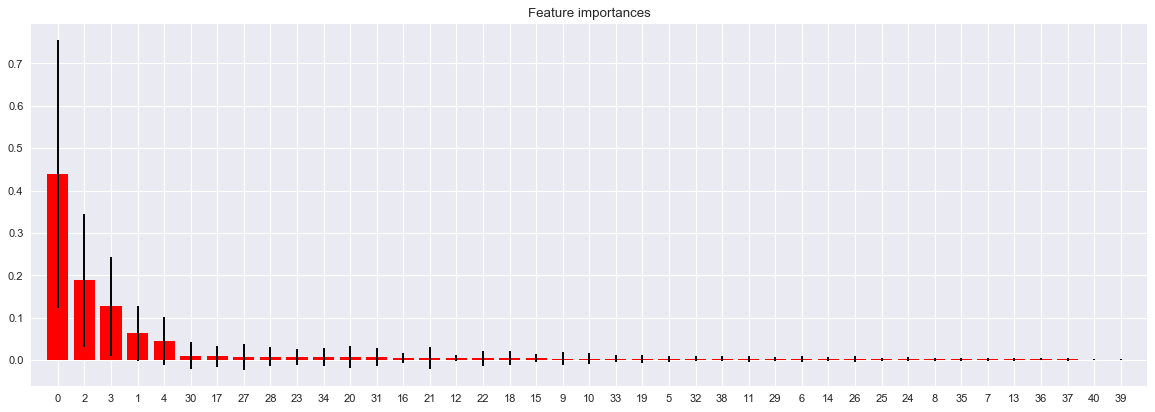

In [22]:
fig, ax = plt.subplots(figsize=(18, 6), dpi=80)

ax.bar(range(X_train.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
ax.set_title('Feature importances')
plt.xticks(range(X_train.shape[1]), indices)
ax.set_xlim([-1, X_train.shape[1]])
plt.show()

In [23]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Feature Importance': forest.feature_importances_}).sort_values('Feature Importance', ascending=False)
feature_importance

,Feature,Feature Importance
0,koi_score,0.439103
2,koi_fpflag_ss,0.188384
3,koi_fpflag_co,0.127413
1,koi_fpflag_nt,0.063416
4,koi_fpflag_ec,0.044610
30,koi_steff_err1,0.010003
17,koi_depth,0.008464
27,koi_model_snr,0.007854
28,koi_tce_plnt_num,0.007601
23,koi_teq,0.007488


Забележуваме дека првите пет карактеристики носат корисна информација, но сепак ќе се обидеме да ги тренираме моделите со тие карактеристики што имаат importance поголема или еднаква од 0,006. Оваа вредност ја избравме интуитивно.

In [24]:
features_to_keep = feature_importance[feature_importance['Feature Importance'] >= 0.006].Feature.values

In [25]:
X_train = X_train[features_to_keep]
X_test = X_test[features_to_keep]

###### Standardization (Z-score Normalization)

In [26]:
def standardization(df):
    """
    Function to standardize data
    """
    if df.min() < df.max(): # Skip constant value column
        df = (df - df.mean())/df.std()
    return df

In [27]:
for feature in features_to_keep:
    X_train[feature] = standardization(X_train[feature])

In [28]:
for feature in features_to_keep:
    X_test[feature] = standardization(X_test[feature])

###### Label Encoding the Output Feature

In [29]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

##### IV.4.2 Графици <a class="anchor" id="section_4_4_2"></a>

###### Distribution of values in single variable

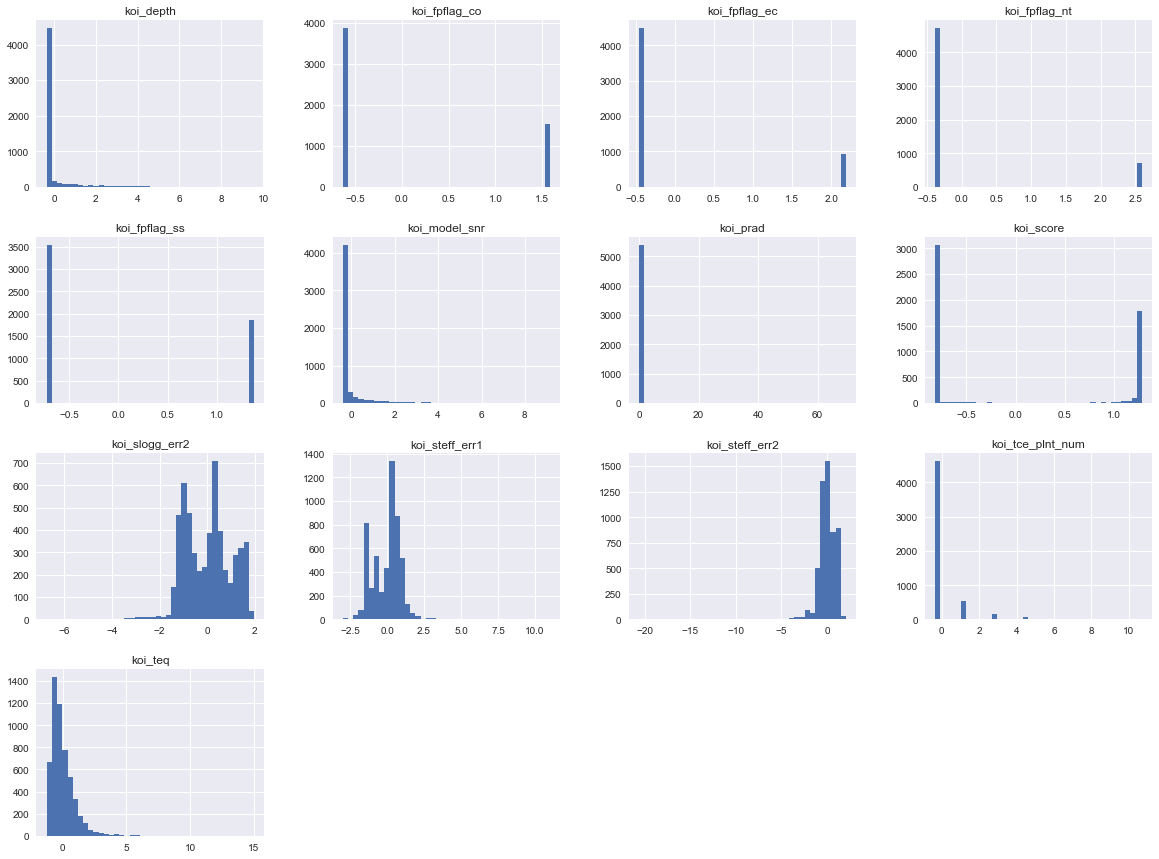

In [30]:
X_train.hist(bins=40, figsize=(20,15))
plt.show()

- Дел од карактеристиките имаат десно накосена, а дел лево накосена распределба, а исто така забележуваме дека кај повеќе каратеристики и повеќемодалност. Кај повеќемодалните карактеристики подобра мерка за податоците е средната вредност, наместо медијаната.

###### Relationship Between Two Variables

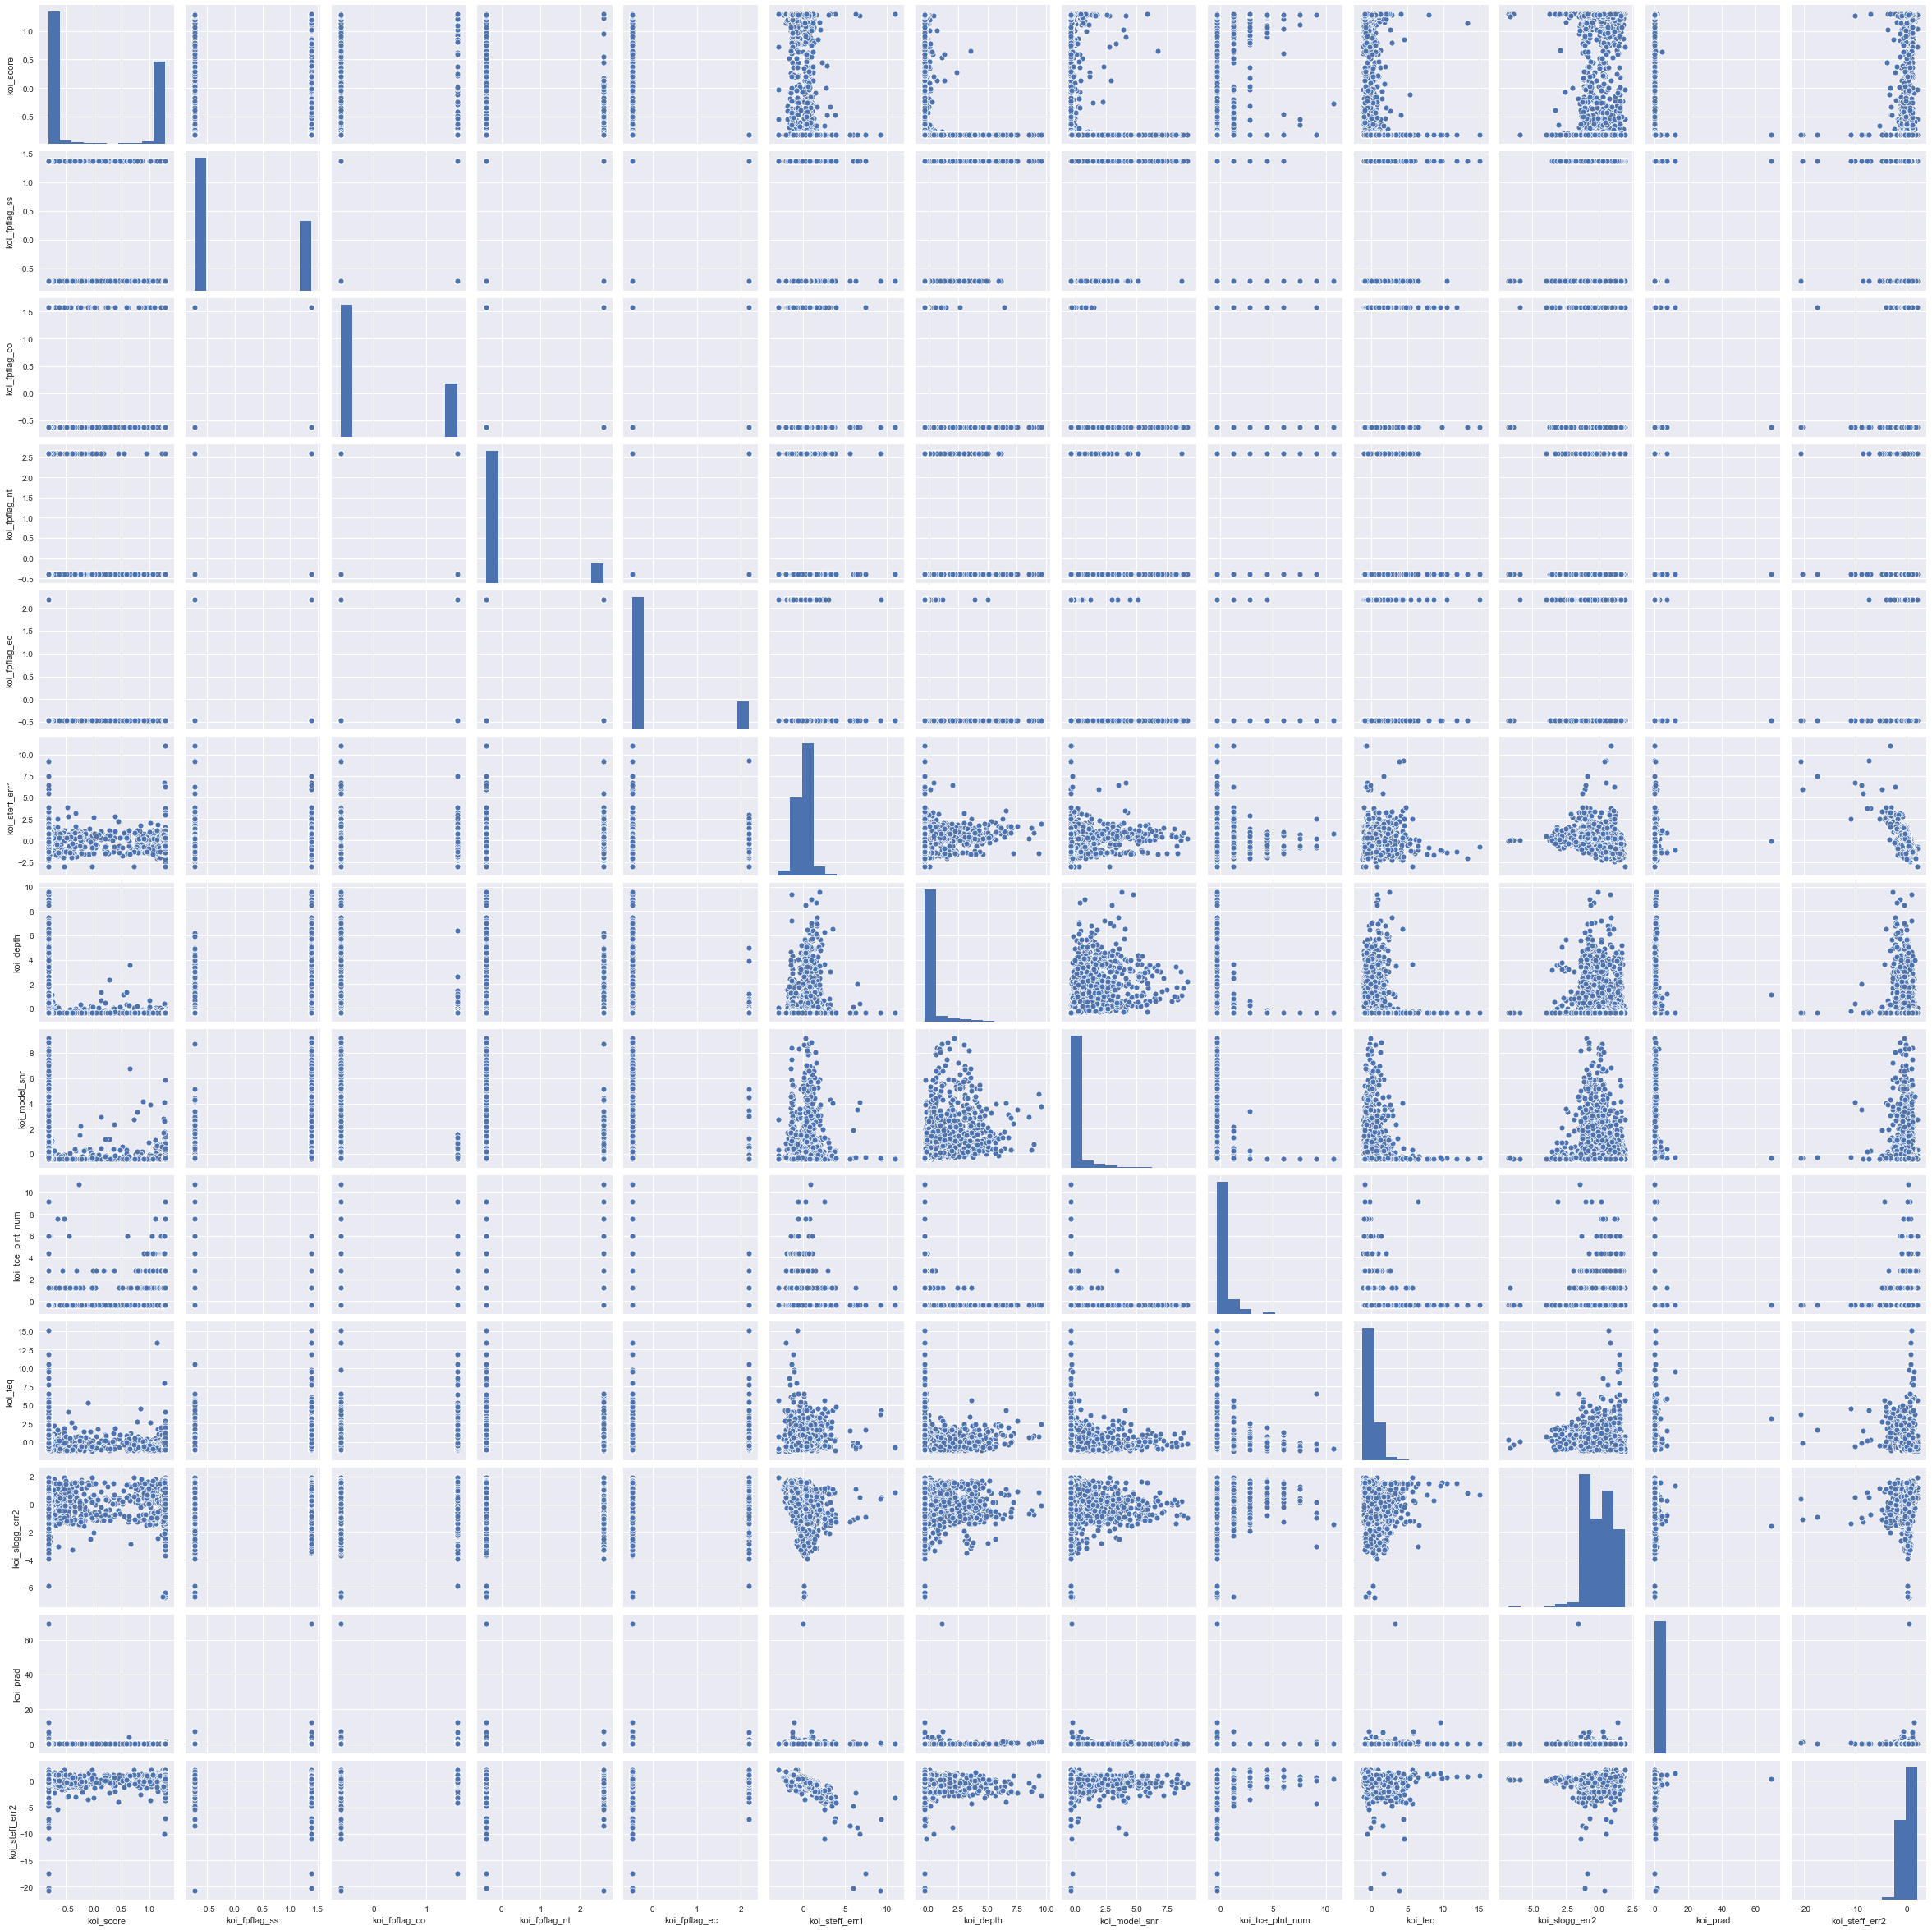

In [31]:
sns.pairplot(X_train)
plt.show()

- Не можеме да забележиме некои линии или други теркови (анг. patterns).
- Не можеме да забележиме некакви зависности помеѓу карактеристиките (линеарни, квадратни, логаритамски итн).
- Не можеме да забележиме кластери.

#### IV.5 Тренирање на моделите <a class="anchor" id="section_4_5"></a>
За тренирањето на моделите да биде попрегледно, ќе го направиме тоа со функцијата **train_classifier(clf, X, y)**, каде што како аргументи предаваме инстанца од класата на моделот, влезните карактеристики и излезната карактеристика од множеството за тренирање.

In [32]:
def train_classifier(clf, X, y):
    """
    Function to fit a classifier to the training data
    """
    print(f'Trainig of model: {clf.__class__.__name__}')
    clf.fit(X, y)

##### IV.5.1 Logistic Regression <a class="anchor" id="section_4_5_1"></a>
Logistic regression е линеарен модел за класификација. Овој модел ја дава веројатноста бараната карактеристика да биде од едниот или од другиот тип, во случајов дали снимениот објект е планета или не. Веројатноста е моделирана преку логистичката функција:

$ f(z) = \frac{1}{1+e^{-z}} $

Logistic regression е многу едноставен алгоритам кој вообичаено има голема ефикасност во предвидувањето. Сепак, кај податочни множества со многу димензии се јавува проблем на претренирање. Можно е да се соочиме со овој проблем бидејќи преку feature selesction одбравме 13 карактеристики. За овој модел потребно е да има умерена или никаква корелација. Поради тоа, доколку две карактеристики имаат висока корелација, во моделот треба да се користи само едната. Треба да се користат само релевантни карактеристики, бидејќи во спротивно може да дава многу погрешни резултати. Потребно е да имаме големо податочно множество, па тоа може да биде предност бидејќи имаме 5414 редови во множеството за тренирање.

In [33]:
model_A = LogisticRegression()

train_classifier(model_A, X_train, y_train)

Trainig of model: LogisticRegression


##### IV.5.2 Support Vector Machines <a class="anchor" id="section_4_5_2"></a>
Support Vector Machines е погоден модел за бинарна класификација на големи податочни множества. Скалабилен е за повеќедимензионални податочни множества. Ризикот од претренирање е помал во однос на други модели. Ќе ја искористиме класата C-Support Vector Classification. Тешкотијата кај овој модел е да се избере соодветна јадрена функција (анг. kernel function). Ќе го тренираме овој модел со преддефинираната јадрена функција rbf, па понатаму со нагодување на хипер-параметрите ќе оцениме дали ова било добар избор или не.

In [34]:
model_B = SVC()

train_classifier(model_B, X_train, y_train)

Trainig of model: SVC


##### IV.5.3 k-Nearest Neighbors <a class="anchor" id="section_4_5_3"></a>
Моделот не прави претпоставка за распределбата на податоците, па е ефикасен за податочно множество каде распределбата не е позната, и поради тоа е робустен. Нема добри перформанси за големи податочни множества и множества со многу димензии затоа што е тешко да го пресмета растојанието помеѓу секоја димензија. Поради тоа, можно е овој модел да не даде задоволителни резултати. Мораме да направиме стандардизација или нормализација на карактеристиките, инаку во спротивно може да даде погрешни предвидувања.

In [35]:
model_C = KNeighborsClassifier()

train_classifier(model_C, X_train, y_train)

Trainig of model: KNeighborsClassifier


##### IV.5.4 Naive Bayes <a class="anchor" id="section_4_5_4"></a>
Naive Bayes се темели на Bayes-овата теорема:

$ P(y|X) = \frac{P(X|y)P(y)}{P(X)} $

Овој модел се темели на претпоставката дека помеѓу податоците има условна зависност, па доколку оваа претпоставка е исполнета, треба да конвергира релативно побрзо од други модели.

За решавање на проблемот одбравме Gaussian Naive Bayes. Овој класификатор смета дека одбироците имаат Gauss-ова распределба. Сепак, од EDA можеме да забележиме дека карактеристиките кои ги одбравме ниедна нема нормална Gauss-ова распределба, туку или се накосени десно или накосени налево, а има и карактеристики кои се повеќемодални, така што овој модел најверојатно ќе има лоши перформанси.

In [36]:
model_D = GaussianNB()

train_classifier(model_D, X_train, y_train)

Trainig of model: GaussianNB


##### IV.5.5 Decision Trees <a class="anchor" id="section_4_5_5"></a>
Decision Trees е едниот од најпопуларните модели поради тоа што има добри перформанси во присуство на шум, толеранција кон вредноси кои недостасуваат, ниска пресметковна цена, и брзо време на извршување.

In [37]:
model_E = DecisionTreeClassifier()

train_classifier(model_E, X_train, y_train)

Trainig of model: DecisionTreeClassifier


##### IV.5.6 Random Forest <a class="anchor" id="section_4_5_6"></a>
Random Forest вообичаено е подобар модел од Decision Trees затоа што е шума од случајно креирани дрва на одлучување, така што наверојатно овој модел ќе има подобри перформанси. Преку вкрстена валидација обезбедуваме поголема точност во предвидувањето. Моќен е кај големи податочни множества со повеќе димензии. Доколку користиме повеќе дрва ги намалуваме шансите за претренирање на моделот, па ова ќе нѝ биде една од целите кога ќе ги нагодуваме хипер-параметрите на моделите.

In [38]:
model_F = RandomForestClassifier()

train_classifier(model_F, X_train, y_train)

Trainig of model: RandomForestClassifier


#### IV.6 Вкрстена валидација <a class="anchor" id="section_4_6"></a>
 
За да ја провериме точноста на моделите ќе направиме вкрстена валидација на множество за тренирање.

Точноста на вкрстената валидација се резимира со средната вредност од точноста од секое подмножество, и оваа вредност ќе ја кориситме како бенчмарк за подобрување на точноста на моделите при нагодување на нивните хипер-параметри. 

За да го автоматизираме овој процес, ќе ја искористиме функцијата каде што правиме десеткратна вкрстена валидација **cross_validation(model, X, y)**, каде што како аргументи предаваме инстанцата од класата на моделот, влезните карактеристики од множество за тренирање и излезната карактеристика од множество за тренирање, а ги добиваме точностите од секоја валидација, и нивните средна вредност и варијанса.

cross_val_score() преддефинирано прави стратифицирана вркстена валидација доколку работиме со класификатори така што не треба да го обезбедиме тој услов.

In [39]:
def cross_validation(model, X, y):
    """
    Function to do ten-fold cross-validation
    """
    scores = cross_val_score(model, X, y, cv=10)
    print(f'Cross-validation scores: {scores}')
    
    print(f'Average cross-validation score: {scores.mean():.5f}')
    
    print(f'Variance in the accuracy between folds: {scores.var():.5f}')
    
    return scores.mean()

###### A) Logistic Regression

In [40]:
score_A = cross_validation(model_A, X_train, y_train)

Cross-validation scores: [0.99815498 0.99630996 0.99630996 1.         0.99630314 1.
 0.99445471 1.         0.99630314 0.99815157]
Average cross-validation score: 0.99760
Variance in the accuracy between folds: 0.00000


Средната вредност од вкрстената валидација е 0,99760, така што очекуваме моделот да е точен 99,76% во просек. Варијансата е 0, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

###### B) Support Vector Machines

In [41]:
score_B = cross_validation(model_B, X_train, y_train)

Cross-validation scores: [0.99815498 0.99630996 0.99630996 1.         0.99630314 1.
 0.99445471 1.         0.99630314 0.99815157]
Average cross-validation score: 0.99760
Variance in the accuracy between folds: 0.00000


Средната вредност од вкрстената валидација е 0,99760, така што очекуваме моделот да е точен 99,76% во просек. Варијансата е 0, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

###### C) k-Nearest Neighbors

In [42]:
score_C = cross_validation(model_C, X_train, y_train)

Cross-validation scores: [0.99815498 0.99815498 0.99630996 1.         0.99815157 1.
 0.99260628 0.99815157 0.99445471 1.        ]
Average cross-validation score: 0.99760
Variance in the accuracy between folds: 0.00001


Средната вредност од вкрстената валидација е 0,99760, така што очекуваме моделот да е точен 99,76% во просек. Варијансата е 0,00001, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

###### D) Naive Bayes

In [43]:
score_D = cross_validation(model_D, X_train, y_train)

Cross-validation scores: [0.99446494 0.99261993 0.99446494 1.         0.99630314 1.
 0.99260628 0.99815157 0.99445471 0.99815157]
Average cross-validation score: 0.99612
Variance in the accuracy between folds: 0.00001


Средната вредност од вкрстената валидација е 0,99612, така што очекуваме моделот да е точен 99,612% во просек. Варијансата е 0,00001, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

###### E) Decision Trees

In [44]:
score_E = cross_validation(model_E, X_train, y_train)

Cross-validation scores: [0.99077491 0.99077491 0.98154982 0.98523985 0.99075786 0.987061
 0.99075786 0.99075786 0.98336414 0.987061  ]
Average cross-validation score: 0.98781
Variance in the accuracy between folds: 0.00001


Средната вредност од вкрстената валидација е 0,98781, така што очекуваме моделот да е точен 98,781% во просек. Варијансата е 0,00001, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

###### F) Random Forest

In [45]:
score_F = cross_validation(model_F, X_train, y_train)

Cross-validation scores: [0.99446494 0.99630996 0.99261993 1.         0.99630314 0.99445471
 0.99260628 0.99815157 0.99630314 1.        ]
Average cross-validation score: 0.99612
Variance in the accuracy between folds: 0.00001


Средната вредност од вкрстената валидација е 0,99612, така што очекуваме моделот да е точен 99,612% во просек. Варијансата е 0,00001, што значи дека добро сме го поделиле множеството, и не е чувствително на различното подмножество од вкрстената валидација.

#### IV.7 Нагодување на хипер-параметрите <a class="anchor" id="section_4_7"></a>
Ќе се обидеме да ги нагодиме хипер-параметрите со Exhaustive Grid Search. На овој начин ги испробуваме сите комбинации со различна вредност за хипер-параметрите кои нѝ се од интерес. Ќе го автоматизираме процесот со функцијата **hyper_param_tuning(model, param_grid)**, каде што како аргументи предаваме инстанца од класата од секој модел, и речник кој ги содржи хипер-параметрите кои нѝ се од интерес.

За да го оцениме подобрувањето, ќе ја искористиме функцијата **evaluate_improvement(clf, score_base, score_best)**, каде што како аргумент го предаваме моделот, точноста на моделот како средна вредност од точностите од вкрстената валидација, и точноста на подобрениот моделот како средна вредност од точностите од вкрстената валидација.

GridSearchCV преддефинирано прави стратифицирана вркстена валидација доколку работиме со класификатори така што не треба да го обезбедиме тој услов.

In [46]:
def hyper_param_tuning(model, param_grid, X, y):
    """
    Function to tune hyper-parameters with ten-fold cross-validation
    """
    grid_search = GridSearchCV(model,
                               param_grid,
                               cv=10,
                                ).fit(X, y)
    
    print(f'Best mean score: {grid_search.best_score_:.2f}')
    print(f'Best parameters: {grid_search.best_params_}')
    print(f'Best estimator: {grid_search.best_estimator_}\n')
    
    return grid_search
    
def evaluate_improvement(clf, score_base, score_best):
    """
    Function to evaluate improvment of the model after hyper-parameter tuning
    """
    improvment = np.round(((score_best - score_base)/score_base)*100, 4)
    
    print(f'Base mean accuracy score of model {clf.__class__.__name__}: {score_base:0.4f}')
    print(f'Improved mean accuracy score of model {clf.__class__.__name__}: {score_best:0.4f}')
    print(f'Improvement of model {clf.__class__.__name__}: {improvment:0.4f}%')

###### A) Logistic Regression
Кај Logistic Regression ќе го нагодуваме хипер-параметарот C кој е инверзен параметар на регуларизација. Регуларизацијата ја користиме за да го избегнеме ризикот од претренирање.

In [47]:
C = [0.001, 0.01, 0.1, 1, 10, 30, 100]

param_grid_A = {'C': C,
               }

grid_search_A = hyper_param_tuning(model_A, param_grid_A, X_train, y_train)

Best mean score: 1.00
Best parameters: {'C': 30}
Best estimator: LogisticRegression(C=30, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)



In [48]:
model_A = grid_search_A.best_estimator_

train_classifier(model_A, X_train, y_train)

best_score_A = cross_validation(model_A, X_train, y_train)

evaluate_improvement(model_A, score_A, best_score_A)

Trainig of model: LogisticRegression
Cross-validation scores: [0.99815498 0.99630996 0.99630996 1.         0.99630314 1.
 0.99445471 1.         0.99815157 0.99815157]
Average cross-validation score: 0.99778
Variance in the accuracy between folds: 0.00000
Base mean accuracy score of model LogisticRegression: 0.9976
Improved mean accuracy score of model LogisticRegression: 0.9978
Improvement of model LogisticRegression: 0.0185%


###### B) Support Vector Machines
Кај Support Vector Machines ќе ги нагодуваме следниве хипер-параметри:
- параметарот на регуларизација C,
- јадрената функција kernel,
- коефициент за нелинеарните јадрени функции gamma.

In [49]:
C = [0.001, 0.01, 0.1, 1, 10, 100]
kernel = ['linear', 'rbf']
gamma = [0.001, 0.01, 1, 10, 100]

param_grid_B = {'C': C,
                'kernel': kernel,
                'gamma': gamma
               }

grid_search_B = hyper_param_tuning(model_B, param_grid_B, X_train, y_train)

Best mean score: 1.00
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'linear'}
Best estimator: SVC(C=100, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.001, kernel='linear',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)



In [50]:
model_B = grid_search_B.best_estimator_

train_classifier(model_B, X_train, y_train)

best_score_B = cross_validation(model_B, X_train, y_train)

evaluate_improvement(model_B, score_B, best_score_B)

Trainig of model: SVC
Cross-validation scores: [0.99815498 0.99630996 0.99815498 1.         0.99630314 1.
 0.99445471 1.         0.99630314 0.99815157]
Average cross-validation score: 0.99778
Variance in the accuracy between folds: 0.00000
Base mean accuracy score of model SVC: 0.9976
Improved mean accuracy score of model SVC: 0.9978
Improvement of model SVC: 0.0185%


###### C) k-Nearest Neighbors
Кај k-Nearest Neighbors ќе ги нагодуваме следниве хипер-параметри:
- бројот k за најблиски соседи n_neighbors,
- број на листови за алгоритмите BallTree или KDTree leaf_size,
- степенскиот параметар кај метриката на Minkowski p.

In [51]:
n_neighbors = np.arange(1, 5)
leaf_size = np.arange(1, 10)
p = [1, 2]

param_grid_C = {'n_neighbors': n_neighbors,
                'leaf_size': leaf_size,
                'p': p
               }

grid_search_C = hyper_param_tuning(model_C, param_grid_C, X_train, y_train)

Best mean score: 1.00
Best parameters: {'leaf_size': 1, 'n_neighbors': 3, 'p': 2}
Best estimator: KNeighborsClassifier(algorithm='auto', leaf_size=1, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')



In [52]:
model_C = grid_search_C.best_estimator_

train_classifier(model_C, X_train, y_train)

best_score_C = cross_validation(model_C, X_train, y_train)

evaluate_improvement(model_C, score_C, best_score_C)

Trainig of model: KNeighborsClassifier
Cross-validation scores: [0.99815498 0.99815498 0.99630996 1.         0.99815157 1.
 0.99445471 0.99815157 0.99445471 1.        ]
Average cross-validation score: 0.99778
Variance in the accuracy between folds: 0.00000
Base mean accuracy score of model KNeighborsClassifier: 0.9976
Improved mean accuracy score of model KNeighborsClassifier: 0.9978
Improvement of model KNeighborsClassifier: 0.0185%


###### D) Naive Bayes
Naive Bayes нема хипер-параметри, така што не правиме нагодување на хипер-параметри за овој модел.

###### E) Decision Trees
Кај Decision Trees ќе ги нагодуваме следниве хипер-параметри:
- максимален број листови во дрвото max_depth,
- број на карактеристики да се земат предвид на секое поделување max_features,
- максимален број на листови max_leaf_nodes.

In [53]:
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 11)]
max_depth.append(None)
# Number of features to consider at every split
max_features = ['sqrt', 'log2']
max_features.append(None)
# Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity.
max_leaf_nodes = np.arange(2, 50)
max_leaf_nodes = np.append(max_leaf_nodes, None)

param_grid_E = {'max_depth': max_depth,
                'max_features': max_features,
                'max_leaf_nodes': max_leaf_nodes
               }

grid_search_E = hyper_param_tuning(model_E, param_grid_E, X_train, y_train)

Best mean score: 0.99
Best parameters: {'max_depth': 80, 'max_features': None, 'max_leaf_nodes': 24}
Best estimator: DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=80, max_features=None, max_leaf_nodes=24,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')



In [54]:
model_E = grid_search_E.best_estimator_

train_classifier(model_E, X_train, y_train)

best_score_E = cross_validation(model_E, X_train, y_train)

evaluate_improvement(model_E, score_E, best_score_E)

Trainig of model: DecisionTreeClassifier
Cross-validation scores: [0.99261993 0.98892989 0.99077491 0.99630996 0.99630314 0.98890943
 0.99260628 0.99445471 0.99260628 0.99075786]
Average cross-validation score: 0.99243
Variance in the accuracy between folds: 0.00001
Base mean accuracy score of model DecisionTreeClassifier: 0.9878
Improved mean accuracy score of model DecisionTreeClassifier: 0.9924
Improvement of model DecisionTreeClassifier: 0.4674%


###### F) Random Forest
Кај Random Forest ќе ги нагодуваме следниве хипер-параметри:
- број на случајни дрва во шумата n_estimators,
- максимален број нивоа во дрвата max_depth,
- метод за одбирање примероци за тренирање на секое дрво bootstrap.

In [55]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 500, stop = 1000, num = 10)]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 10)]
max_depth.append(None)
# Method of selecting samples for training each tree
bootstrap = [True, False]
    
param_grid_F = {'n_estimators': n_estimators,
                'max_depth': max_depth,
                'bootstrap': bootstrap
               }

grid_search_F = hyper_param_tuning(model_F, param_grid_F, X_train, y_train)

Best mean score: 1.00
Best parameters: {'bootstrap': False, 'max_depth': 12, 'n_estimators': 500}
Best estimator: RandomForestClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=12, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=500,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)



In [56]:
model_F = grid_search_F.best_estimator_

train_classifier(model_F, X_train, y_train)

best_score_F = cross_validation(model_F, X_train, y_train)

evaluate_improvement(model_F, score_F, best_score_F)

Trainig of model: RandomForestClassifier
Cross-validation scores: [0.99446494 0.99630996 0.99446494 1.         0.99815157 0.99630314
 0.99445471 0.99815157 0.99630314 1.        ]
Average cross-validation score: 0.99686
Variance in the accuracy between folds: 0.00000
Base mean accuracy score of model RandomForestClassifier: 0.9961
Improved mean accuracy score of model RandomForestClassifier: 0.9969
Improvement of model RandomForestClassifier: 0.0742%


#### IV.8 Метрика за евалуација на моделите <a class="anchor" id="section_4_8"></a>

За да провериме како се генерализира моделот на податоци со кои првпат се сретнува ќе ја искористиме функцијата **predict(clf, X)**, каде што како аргументи предаваме инстанца од класата на моделот и влезните карактеристики за тестирање, а добиваме вектор од предвидените податоци.

Перформансите на моделите ќе ги евалуираме со $ F_1 $ score и матрица на конфузија. 

$ F_1 $ score е многу ефикасна мерка кај класификација со небалансирано податочно множество. Најдобрата вредност за $ F_1 $ score е 1, а најлошата вредност е 0.

Матрицата на конфузија $ C $ е приказ за точноста на класификацијата. Кај бинарна класификација бројот на точни негативни примероци е $ C_{00} $, неточни негативни примероци $ C_{10} $, точни позитивни примероци $ C_{11} $, и неточни позитивни примероци $ C_{01} $.

Евалуацијата на моделите ќе ја направиме со функцијата **metrics(clf, X, y, y_pred)**, каде како аргумент предаваме инстанца од класата на моделот, влезните карактеристики од множеството за тестирање, излезната карактеристика од множеството за тестирање, и векторот од предвидените класи, а на излез ги добиваме $ F_1 $ score и матрица на конфузија.

In [57]:
def predict(clf, X):
    """
    Function to predict class labels for samples in testing data
    """
    print(f'Predicting class labels of model: {clf.__class__.__name__}')
    y_pred = clf.predict(X)
    return y_pred

def metrics(clf, X, y, y_pred):
    """
    Function to compute classification metrics using the F1 score and confusion matrix
    """
    F1_score = f1_score(y, y_pred)
    
    print(f'Evaluation of model: {clf.__class__.__name__}')
    print(f'F1 score: {F1_score:.4f}')
    print(f'Confusion matrix:\n')
    plt.rcParams.update({'font.size': 16})
    plot_confusion_matrix(clf, X, y, display_labels=['FALSE POSITIVE', 'CONFIRMED'], cmap=plt.cm.Blues, values_format='d')
    plt.show()
    
    return F1_score

###### A) Logistic Regression

Predicting class labels of model: LogisticRegression
Evaluation of model: LogisticRegression
F1 score: 0.9412
Confusion matrix:



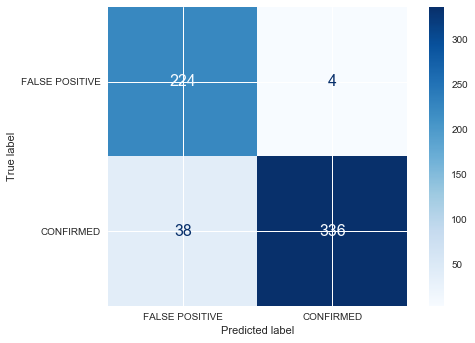

In [58]:
y_pred_A = predict(model_A, X_test)

F1_score_A = metrics(model_A, X_test, y_test, y_pred_A)

###### B) Support Vector Machines

Predicting class labels of model: SVC
Evaluation of model: SVC
F1 score: 0.9382
Confusion matrix:



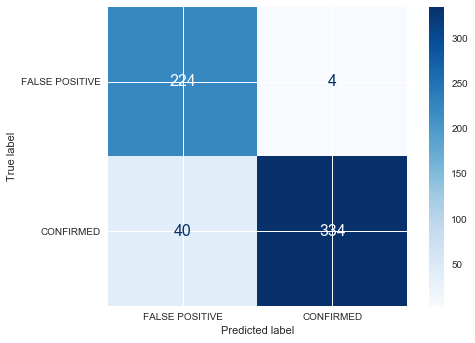

In [59]:
y_pred_B = predict(model_B, X_test)

F1_score_B = metrics(model_B, X_test, y_test, y_pred_B)

###### C) k-Nearest Neighbors

Predicting class labels of model: KNeighborsClassifier
Evaluation of model: KNeighborsClassifier
F1 score: 0.9497
Confusion matrix:



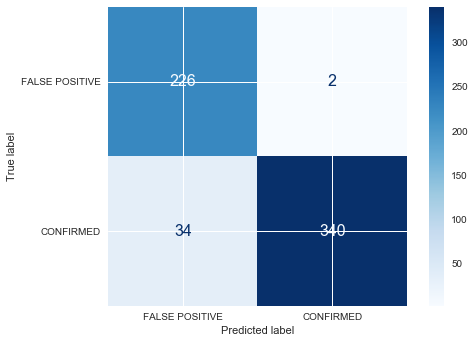

In [60]:
y_pred_C = predict(model_C, X_test)

F1_score_C = metrics(model_C, X_test, y_test, y_pred_C)

###### D) Naive Bayes

Predicting class labels of model: GaussianNB
Evaluation of model: GaussianNB
F1 score: 0.7664
Confusion matrix:



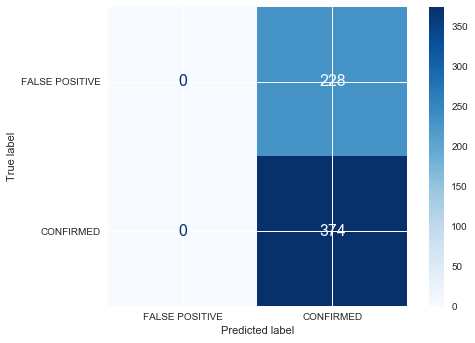

In [61]:
y_pred_D = predict(model_D, X_test)

F1_score_D = metrics(model_D, X_test, y_test, y_pred_D)

###### E) Decision Trees

Predicting class labels of model: DecisionTreeClassifier
Evaluation of model: DecisionTreeClassifier
F1 score: 0.9814
Confusion matrix:



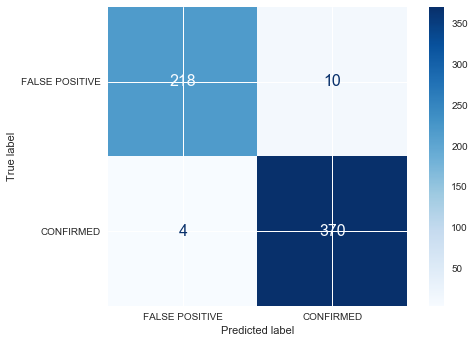

In [62]:
y_pred_E = predict(model_E, X_test)

F1_score_E = metrics(model_E, X_test, y_test, y_pred_E)

###### F) Random Forest

Predicting class labels of model: RandomForestClassifier
Evaluation of model: RandomForestClassifier
F1 score: 0.9840
Confusion matrix:



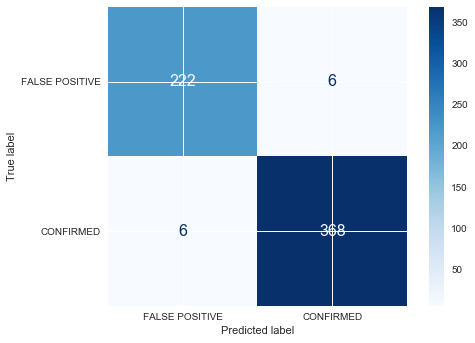

In [63]:
y_pred_F = predict(model_F, X_test)

F1_score_F = metrics(model_F, X_test, y_test, y_pred_F)

#### IV.9 Избор на модел <a class="anchor" id="section_4_9"></a>

Со оглед на тоа што го користиме $ F_1 $ score како показател за перформансите на секој модел, ќе формираме DataFrame со $ F_1 $ score за секој модел, и како модел за решавање на проблемот детекција на егзопланети со мисијата Kepler ќе го земеме оној кој има најголем $ F_1 $ score.

Во табелата подолу се дадени $ F_1 $ score за секој од моделите добиени со примена на моделите по направеното нагодување на хипер-параметрите врз множеството за тестирање.

In [64]:
f1_scores = dict()
f1_scores.update({model_A.__class__.__name__: F1_score_A})
f1_scores.update({model_B.__class__.__name__: F1_score_B})
f1_scores.update({model_C.__class__.__name__: F1_score_C})
f1_scores.update({model_D.__class__.__name__: F1_score_D})
f1_scores.update({model_E.__class__.__name__: F1_score_E})
f1_scores.update({model_F.__class__.__name__: F1_score_F})

In [65]:
best_model = pd.DataFrame({'Model': list(f1_scores.keys()), 'F1 Score': list(f1_scores.values())})
best_model['F1 Score'] = best_model['F1 Score'].round(decimals=4)
best_model.sort_values('F1 Score', ascending=False)

,Model,F1 Score
5,RandomForestClassifier,0.9840
4,DecisionTreeClassifier,0.9814
2,KNeighborsClassifier,0.9497
0,LogisticRegression,0.9412
1,SVC,0.9382
3,GaussianNB,0.7664


Заклучуваме дека Random Forest дава најдобри резултати, па затоа ќе го избереме овој модел за откривање на планети во податочното множество.

### V. Откривање планети <a class="anchor" id="chapter5"></a>

Откако го одбравме моделот Random Forests за овој проблем, сега ќе го примениме врз податочното множество каде што треба да утврдиме кои од снимените објекти се планети.

Ова ќе го направиме со функцијата **discover_possible_exoplanets(clf, X_candidates, candidates)** (адаптирана од \[[30](#ref30)\]), каде што како аргументи ги предаваме инстанцата на класата за моделот Random Forests, процесираното множество кое ги содржи кандидатите за планети, и истото множество непроцесираното, а на излез го добиваме бројот на планети, бројот на објекти што не се планети, колкав процент од множеството се планети, а исто така се ажурира и непроцесираното множеството со новиот статус на објектот.

In [66]:
def discover_possible_exoplanets(clf, X_candidates, candidates):
    # Setting up confirmed and false positive array
    confirmed = []
    false_positive = []
    
    # Predicting the candidate exoplanets
    results = pd.Series(predict(clf, X_candidates), index=candidates.index)
    candidates.insert(3, 'koi_disposition_pred', results)
    
    # Looping trough all the planets predictions
    for index, planet in candidates.iterrows():
        if planet['koi_disposition_pred'] == 1:
            confirmed.append({ 'name': planet['kepoi_name'], 'index': planet.index})
        else:
            false_positive.append({'name': planet['kepoi_name'], 'index': planet.index})

    discovery_rate = float(len(confirmed))/candidates.shape[0]*100

    print(f'\nExoplanets: {len(confirmed)} have been Confirmed!')
    print(f'\nExoplanets: {len(false_positive)} are False Positive!')
    print(f'\nDiscovery Rate: {discovery_rate:.4f}%')

Прво го претпроцесираме множестовото со кандидати за да го подготвиме за избраниот модел.

In [67]:
X_candidates = candidates.loc[:, features_to_keep]

In [68]:
for feature in features_to_keep:
    X_candidates[feature] = standardization(X_candidates[feature])

In [69]:
X_candidates

,koi_score,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_nt,koi_fpflag_ec,koi_steff_err1,koi_depth,koi_model_snr,koi_tce_plnt_num,koi_teq,koi_slogg_err2,koi_prad,koi_steff_err2
2,-2.920559,-0.033464,0,-0.023656,0,0.483866,2.167657,0.427297,-0.440599,-0.468656,-0.692247,0.770762,-0.436333
37,0.568115,-0.033464,0,-0.023656,0,-1.245899,1.942458,6.915917,-0.440599,0.419815,0.287403,0.588410,1.134449
58,0.564626,-0.033464,0,-0.023656,0,0.932324,1.145253,0.015088,-0.440599,-0.795384,0.361619,0.229808,-0.230068
62,0.543694,-0.033464,0,-0.023656,0,-1.203189,-0.139282,-0.227633,1.014763,-0.285230,0.970189,1.140808,1.102716
63,0.118076,-0.033464,0,-0.023656,0,-0.669310,-0.259268,-0.279944,2.470126,0.742722,0.317089,-0.301227,0.531523
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,0.020393,-0.033464,0,-0.023656,0,1.338071,-0.253976,-0.269482,-0.440599,1.071361,-0.083677,-0.216536,-1.483520
9542,-2.261200,-0.033464,0,-0.023656,0,1.124520,-0.007766,-0.231818,-0.440599,-1.181344,-1.285975,-0.094459,-1.213790
9552,-1.109937,-0.033464,0,-0.023656,0,0.313025,0.028266,-0.259020,-0.440599,-1.252040,-0.603188,-0.059362,-0.277668
9560,-1.186688,-0.033464,0,-0.023656,0,0.633352,-0.253571,-0.260066,-0.440599,1.384714,-1.404720,-0.288256,-1.134457


In [70]:
discover_possible_exoplanets(model_F, X_candidates, candidates)

Predicting class labels of model: RandomForestClassifier

Exoplanets: 460 have been Confirmed!

Exoplanets: 1327 are False Positive!

Discovery Rate: 25.7415%


Според нашиот модел, детектиравме дека 460 од снимените објекти се егзопланети, а 1327 не се егзопланети, односно 25,7415% од непознатите објекти се егзопланети.

Според \[[32](#ref32)\], со мисијата Kepler се откриени 2662 егзопланети. Првиот дел од множеството кое ги содржи објектите за кои се знае што се, и кое го користевме за тренирање и тестирање на моделите содржи 2281 егзопланета. Со нашиот модел, Random Forests, во другиот дел од податочното множество кое содржи кандидати за планети, откривме 460 планети, па можеме да кажеме дека со работата на овој проект вкупно откривме 2741 егзопланета, односно 79 егзопланети или приближно 2,9677% повеќе од официјалните резултати. Сметаме дека е фер да се заклучи дека резултатите од овој проект се задоволителни.

In [71]:
candidates

,kepid,kepoi_name,koi_disposition,koi_disposition_pred,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
2,10811496,K00753.01,CANDIDATE,1,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
37,11138155,K00760.01,CANDIDATE,0,CANDIDATE,1.000,0,0,0,0,...,-77.0,4.359,0.110,-0.110,1.082,0.173,-0.130,292.16705,48.727589,15.263
58,11818800,K00777.01,CANDIDATE,1,CANDIDATE,0.999,0,0,0,0,...,-163.0,4.507,0.116,-0.105,0.781,0.116,-0.095,294.31686,50.080231,15.487
62,11918099,K00780.02,CANDIDATE,0,CANDIDATE,0.993,0,0,0,0,...,-79.0,4.595,0.012,-0.064,0.765,0.055,-0.028,293.83331,50.230350,15.334
63,9579641,K00115.03,CANDIDATE,0,CANDIDATE,0.871,0,0,0,0,...,-115.0,4.339,0.132,-0.108,1.087,0.157,-0.142,287.88733,46.276241,12.791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,9938836,K07978.01,CANDIDATE,1,CANDIDATE,0.843,0,0,0,0,...,-242.0,3.890,0.405,-0.135,2.219,0.536,-0.996,285.30768,46.829803,13.729
9542,10011213,K07982.01,CANDIDATE,1,CANDIDATE,0.189,0,0,0,0,...,-225.0,4.488,0.054,-0.216,0.955,0.291,-0.097,291.60455,46.973289,15.632
9552,10028127,K08193.01,CANDIDATE,1,CANDIDATE,0.519,0,0,0,0,...,-166.0,4.561,0.030,-0.170,0.855,0.207,-0.069,297.73398,46.961529,15.719
9560,10128825,K07986.01,CANDIDATE,1,CANDIDATE,0.497,0,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757


### VI. Еволуција на решението <a class="anchor" id="chapter6"></a>

- Откако ги отстранивме вредностите кои недостасуваат, повторно се јави проблемот податочното множество да не е балансирано, така што најверојатно подобро решение е веднаш откако ќе се вчита податочното множество да се отстранат сите вредности кои недостасуваат, па потоа да се подели на множества за тренирање, и за тестирање, и на крај да се претпроцесира множеството за тренирање.
- Определивме матрица на корелација, меѓутоа брзо заклучивме дека при проблем на класификација не нѝ е од полза. Затоа направивме feature importance со forests of trees.
- Kaj Random Forest недостaтокот за големи податочни множества да потроши голема меморија и долгото време на обработка дојде до израз. Нагодувањето на хипер-параметрите беше многу тешко, и моравме постојано да го намалуваме бројот на хипер-параметри со цел да добиеме резултат. Извршувањето на таа ќелија траеше повеќе од два часа! Кога би имале на располагање суперкомпјутер или уште подобро квантен компјутер, веројатно ќе имавме резултати многу побрзо.
- На почетокот податочното множество го поделивме на множества за тренирање, за тестирање, и за валидација, но во текот на работењето, се покажа дека ова не е потребно затоа што секоја од функциите инхерентно прави вкрстена валидација, па така можеме да заклучиме дека податочното множество треба да го поделиме само на множества за тренирање, врз кое ќе вршиме претпроцесирање, вкрстена валидација, и нагодување на хипер-параметрите, и за тестирање, како множество со кое моделите прв пат ќе се сретнат. Вкрстената валидација и нагодувањето на хипер-параметрите се многу важни чекори за создавање на ефикасни модели, па поради тоа одговорните за библиотеката scikit-learn го земале предвид ова и го имплементирале во класите за ние корисниците да не го правиме тоа.

### VII. Референци <a class="anchor" id="chapter7"></a>

[1] <a class="anchor" id="ref1"></a> Nationalgeographic.com. 2020. Exoplanets - National Geographic. [online] Available at: <https://www.nationalgeographic.com/science/space/universe/exoplanets/> [Accessed 30 August 2020].

[2] <a class="anchor" id="ref2"></a> Exoplanet Exploration: Planets Beyond our Solar System. 2020. Infographic: Profile Of Planet 51 Pegasi B - Exoplanet Exploration: Planets Beyond Our Solar System. [online] Available at: <https://exoplanets.nasa.gov/resources/289/infographic-profile-of-planet-51-pegasi-b/> [Accessed 30 August 2020].

[3] <a class="anchor" id="ref3"></a> Spaceplace.nasa.gov. 2020. What Is An Exoplanet? | NASA Space Place – NASA Science For Kids. [online] Available at: <https://spaceplace.nasa.gov/all-about-exoplanets/en/> [Accessed 30 August 2020].

[4] <a class="anchor" id="ref4"></a> Exoplanetarchive.ipac.caltech.edu. 2020. Kepler Objects Of Interest. [online] Available at: <https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative> [Accessed 30 August 2020].

[5] <a class="anchor" id="ref5"></a> Exoplanetarchive.ipac.caltech.edu. 2020. Data Columns In Kepler Objects Of Interest Table. [online] Available at: <https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html> [Accessed 30 August 2020].

[6] <a class="anchor" id="ref6"></a> Medium. 2020. 3 Things You Need To Know Before You Train-Test Split. [online] Available at: <https://towardsdatascience.com/3-things-you-need-to-know-before-you-train-test-split-869dfabb7e50> [Accessed 30 August 2020].

[7] <a class="anchor" id="ref7"></a> Building Intelligence Together. 2020. Exploratory Data Analysis - Calculations. [online] Available at: <https://koopingshung.com/blog/exploratory-data-analysis-non-visual/> [Accessed 21 July 2020].

[8] <a class="anchor" id="ref8"></a> Building Intelligence Together. 2020. Exploratory Data Analysis - Using Visualization. [online] Available at: <https://koopingshung.com/blog/exploratory-data-analysis-using-visualization/> [Accessed 21 July 2020].

[9] <a class="anchor" id="ref9"></a> Phl.upr.edu. 2020. HEC: Periodic Table Of Exoplanets - Planetary Habitability Laboratory @ UPR Arecibo. [online] Available at: <http://phl.upr.edu/projects/habitable-exoplanets-catalog/media/pte> [Accessed 31 August 2020].

[10] <a class="anchor" id="ref10"></a> Scikit-learn.org. 2020. 1.13. Feature Selection — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/feature_selection.html#feature-selection> [Accessed 1 September 2020].

[11] <a class="anchor" id="ref11"></a> Scikit-learn.org. 2020. Sklearn.Ensemble.Extratreesclassifier — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html#sklearn.ensemble.ExtraTreesClassifier> [Accessed 1 September 2020].

[12] <a class="anchor" id="ref12"></a> Scikit-learn.org. 2020. Feature Importances With Forests Of Trees — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/auto_examples/ensemble/plot_forest_importances.html#sphx-glr-auto-examples-ensemble-plot-forest-importances-py> [Accessed 1 September 2020].

[13] <a class="anchor" id="ref13"></a> Scikit-learn.org. 2020. Sklearn.Linear_Model.Logisticregression — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression> [Accessed 1 September 2020].

[14] <a class="anchor" id="ref14"></a> OpenGenus IQ: Learn Computer Science. 2020. Advantages And Disadvantages Of Logistic Regression. [online] Available at: <https://iq.opengenus.org/advantages-and-disadvantages-of-logistic-regression/> [Accessed 1 September 2020].

[15] <a class="anchor" id="ref15"></a> Scikit-learn.org. 2020. Sklearn.Svm.SVC — Scikit-Learn 0.23.2 Documentation. [online] Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svc#sklearn.svm.SVC> [Accessed 1 September 2020].

[16] <a class="anchor" id="ref16"></a> Statinfer.com. 2020. 204.6.8 SVM : Advantages Disadvantages And Applications – Statinfer. [online] Available at: <https://statinfer.com/204-6-8-svm-advantages-disadvantages-applications/> [Accessed 1 September 2020].

[17] <a class="anchor" id="ref17"></a> Medium. 2020. In Depth: Parameter Tuning For SVC. [online] Available at: <https://medium.com/all-things-ai/in-depth-parameter-tuning-for-svc-758215394769> [Accessed 1 September 2020].

[18] <a class="anchor" id="ref18"></a> Scikit-learn.org. 2020. Sklearn.Neighbors.Kneighborsclassifier — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier> [Accessed 1 September 2020].

[19] <a class="anchor" id="ref19"></a> Kumar, N., 2020. Advantages And Disadvantages Of KNN Algorithm In Machine Learning. [online] Theprofessionalspoint.blogspot.com. Available at: <http://theprofessionalspoint.blogspot.com/2019/02/advantages-and-disadvantages-of-knn.html> [Accessed 1 September 2020].

[20] <a class="anchor" id="ref20"></a> Brilliant.org. 2020. K-Nearest Neighbors | Brilliant Math & Science Wiki. [online] Available at: <https://brilliant.org/wiki/k-nearest-neighbors/> [Accessed 1 September 2020].

[21] <a class="anchor" id="ref21"></a> Scikit-learn.org. 2020. Sklearn.Naive_Bayes.Gaussiannb — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB> [Accessed 1 September 2020].

[22] <a class="anchor" id="ref22"></a> Scikit-learn.org. 2020. Sklearn.Tree.Decisiontreeclassifier — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier> [Accessed 1 September 2020].

[23] <a class="anchor" id="ref23"></a> Scikit-learn.org. 2020. Sklearn.Ensemble.Randomforestclassifier — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestClassifier.html?highlight=random%20forest#sklearn.ensemble.RandomForestClassifier> [Accessed 1 September 2020].

[24] <a class="anchor" id="ref24"></a> Sharma, A., 2020. Decision Tree Vs. Random Forest - Which Algorithm Should You Use?. [online] Analytics Vidhya. Available at: <https://www.analyticsvidhya.com/blog/2020/05/decision-tree-vs-random-forest-algorithm/> [Accessed 1 September 2020].

[25] <a class="anchor" id="ref25"></a> NewGenApps. 2020. Random Forest Analysis In ML And When To Use It - Newgenapps. [online] Available at: <https://www.newgenapps.com/blog/random-forest-analysis-in-ml-and-when-to-use-it/#:~:text=Why%20use%20Random%20Forest%20Algorithm&text=It%20provides%20higher%20accuracy%20through,fitting%20trees%20in%20the%20model> [Accessed 1 September 2020].

[26] <a class="anchor" id="ref26"></a> Scikit-learn.org. 2020. Sklearn.Metrics.F1_Score — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.metrics.f1_score.html?highlight=f1%20score#sklearn.metrics.f1_score> [Accessed 2 September 2020].

[27] <a class="anchor" id="ref27"></a> Scikit-learn.org. 2020. Sklearn.Metrics.Confusion_Matrix — Scikit-Learn 0.24.Dev0 Documentation. [online] Available at: <https://scikit-learn.org/dev/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix> [Accessed 2 September 2020].

[28] <a class="anchor" id="ref28"></a> Medium. 2020. How To Tune A Decision Tree?. [online] Available at: <https://towardsdatascience.com/how-to-tune-a-decision-tree-f03721801680> [Accessed 2 September 2020].

[29] <a class="anchor" id="ref29"></a> Medium. 2020. Hyperparameter Tuning The Random Forest In Python. [online] Available at: <https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74> [Accessed 2 September 2020].

[30] <a class="anchor" id="ref30"></a> GitHub. 2020. Mitranos/Exoplanets-Discovery-Machine-Learning. [online] Available at: <https://github.com/mitranos/exoplanets-discovery-machine-learning/blob/ac465cb8439deefe68242d86a1757415e00f4645/machine_learning_approach_to_exoplanet_discovery.ipynb> [Accessed 2 September 2020].

[31] <a class="anchor" id="ref31"></a> Müller, A. and Guido, S., 2016. Introduction To Machine Learning With Python: A Guide For Data Scientists. 1st ed. O'Reilly Media.

[32] <a class="anchor" id="ref32"></a>Overbye, D., 2018. Kepler, The Little NASA Spacecraft That Could, No Longer Can. [online] https://www.nytimes.com/. Available at: <https://www.nytimes.com/2018/10/30/science/nasa-kepler-exoplanet.html> [Accessed 26 September 2020].